# Практическое задание: Преобразование категорий и нормализация признаков

Вы работаете аналитиком в банке. Необходимо подготовить данные о заявителях по кредитам для построения модели машинного обучения, которая ***будет прогнозировать решение по кредитной заявке.***

В качестве исходных данных используется датасет `loan_approval_data_2025.csv`.

**Целевая переменная:**

`loan_status` — результат рассмотрения заявки (например, одобрена или отклонена).

Перед обучением модели необходимо выполнить анализ структуры данных, преобразовать категориальные признаки в числовой формат и подготовить числовые признаки с помощью различных методов масштабирования.

Загрузка датасета:

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("Loan_approval_data_2025.csv")

df = pd.DataFrame(data)

# Задачи для выполнения
# Задача 1: Исследовательский анализ данных
Условие: Проведите исследовательский анализ данных.

Определите:
1. Количество строк и столбцов.
2. Какие признаки являются числовыми, а какие — категориальными.
3. Наличие пропущенных значений.

4. Количество уникальных значений для каждого категориального признака.

5. (*) Построить гистограммы распределения для всех числовых признаков.

6. Сделать краткий вывод о структуре набора данных.

In [17]:
df.head(10)

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1
5,CUST100005,32,Employed,13.4,32015,570,7.3,253,1120,0,0,2,Credit Card,Personal,37000,22.92,0.035,1.156,0.385,0
6,CUST100006,53,Employed,22.9,44989,674,11.1,19667,19298,0,0,0,Personal Loan,Home Improvement,45600,11.02,0.429,1.014,0.338,1
7,CUST100007,44,Self-Employed,4.2,80603,625,18.5,830,38382,0,0,0,Credit Card,Personal,51700,19.42,0.476,0.641,0.214,1
8,CUST100008,29,Employed,5.9,28416,569,2.6,1334,22668,1,2,0,Credit Card,Education,33800,22.72,0.798,1.189,0.396,0
9,CUST100009,41,Employed,7.0,70717,638,21.5,1578,21394,0,1,0,Credit Card,Personal,70000,19.35,0.303,0.990,0.330,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [11]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [ ]:
# пропусков
df.isna().sum().sum()

np.int64(0)

In [21]:
# уникальных значений
df[['customer_id', 'occupation_status', 'defaults_on_file', 'product_type', 'loan_intent', 'loan_status']].nunique()

customer_id          50000
occupation_status        3
defaults_on_file         2
product_type             3
loan_intent              6
loan_status              2
dtype: int64

1. Количество строк: 50000
2. Количество столбцов: 20
3. Числовые признаки: age, years_employed, annual_income, credit_score, credit_history_years, savings_assets, current_debt, delinquencies_last_2yrs, derogatory_marks, loan_amount, interest_rate, debt_to_income_ratio, loan_to_income_ratio, payment_to_income_ratio.
4. Категориальные признаки: customer_id, occupation_status, defaults_on_file, product_type, loan_intent, loan_status.
5. Пропусков: 0
6. Уникальных значений:
customer_id          50000
occupation_status        3
defaults_on_file         2
product_type             3
loan_intent              6
loan_status              2

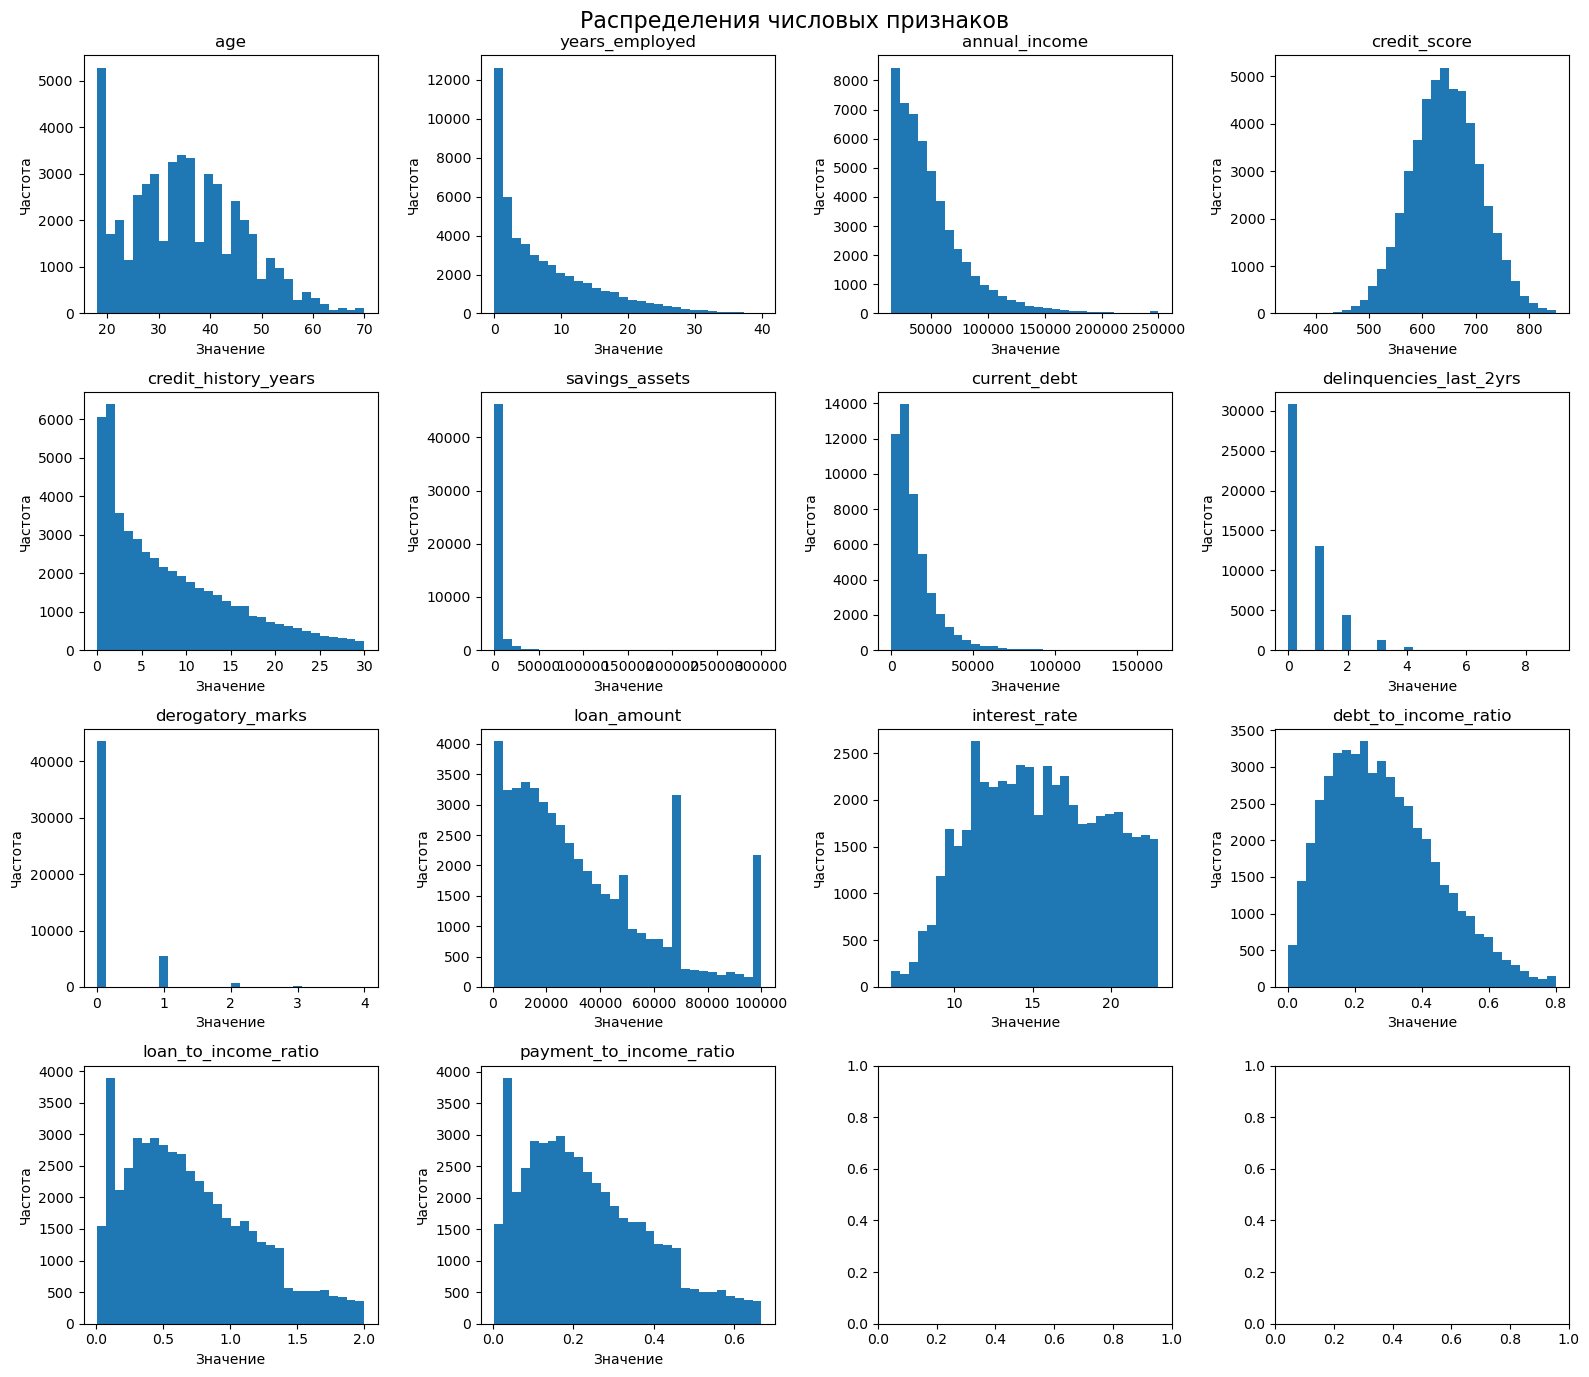

In [ ]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop(['defaults_on_file', 'loan_status'])

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(16, 14)
)

axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    axes[i].hist(df[column], bins=30)
    axes[i].set_title(column)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.suptitle('Распределения числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

Вывод о структуре датасета:

Набор данных содержит 50000 строк и 20 столбцов, характеризующих клиентов и их кредитные заявки. Большинство признаков являются числовыми и описывают возраст, доход, кредитную историю, задолженность, размер займа и прочие финансовые данные. Шесть признаков имеют категориальный тип, при этом customer_id является идентификатором клиента. Пропущенные значения отсутствуют, поэтому предварительная обработка пропусков не требуется. Целевая переменная loan_status является бинарной. Набор данных структурирован и пригоден для дальнейшего анализа.

# Задача 2: Преобразование категориальных признаков
Перед обучением модели необходимо преобразовать категориальные признаки в числовую форму.

**Требования**
1. Выберите один категориальный признак, имеющий небольшое количество уникальных значений, и выполните для него **Label Encoding**.
2. Выберите один номинальный категориальный признак (например, семейное положение, образование, тип занятости или аналогичный признак из датасета) и выполните **One-Hot Encoding**.
3. Выберите категориальный признак с несколькими повторяющимися категориями и выполните **Frequency Encoding**.
4. Создайте новый DataFrame, содержащий исходные числовые признаки и преобразованные категориальные признаки.
5. Сделайте вывод о том, в каких случаях каждый метод кодирования является наиболее подходящим.

**Примечание.**
` Конкретные признаки выбираются студентом исходя из структуры датасета.`

In [12]:
# Сделайте копию датасета
# Напишите ваш код здесь

# Задача 3: Сравнение методов кодирования
Сравните полученные способы кодирования.
**Требования:**

1. Определите, насколько увеличилось количество признаков после применения **One-Hot Encoding**.
2. Для каждого метода постройте визуализацию (*).

**Например:**
* **для Label Encoding** — столбчатую диаграмму распределения полученных кодов;
* **для One-Hot Encoding** — тепловую карту корреляций между созданными бинарными признаками;
*  для **Frequency Encoding** — график распределения полученных значений.
3. Сравните преимущества и недостатки каждого способа кодирования.
4. Сделайте вывод, какой метод предпочтительнее использовать для различных типов категориальных признаков.


In [13]:
# Сделайте копию датасета
# Напишите ваш код здесь

# Задача 4: Масштабирование числовых признаков
Подготовьте числовые признаки к использованию в модели машинного обучения

**Требования**
1. Выберите два числовых признака, характеризующих клиента (например, возраст, доход, стаж работы или аналогичные признаки из датасета), и примените **Min-Max Scaling**.
2. Выберите два других числовых признака и выполните **Standard Scaling**.
3. Для одного числового признака выполните **Robust Scaling** и сравните результат со **Standard Scaling**.
4. (*)Постройте boxplot для выбранных признаков:
* до масштабирования;
* после масштабирования.
5. Рассчитайте основные статистики (**среднее значение, стандартное отклонение, минимум и максимум)** до и после преобразований.
6. Сделайте вывод о том, как различные методы масштабирования влияют на данные и в каких случаях каждый из них рекомендуется использовать.

In [14]:
# Сделайте копию датасета
# Напишите ваш код здесь

## Итоговое задание

Подготовьте набор данных к дальнейшему использованию в задачах машинного обучения.

В результате работы необходимо:

* получить набор данных, содержащий только признаки, пригодные для обучения модели
* преобразовать выбранные категориальные признаки в числовой формат
* выполнить масштабирование выбранных числовых признаков
* сохранить подготовленный DataFrame для дальнейшего использования

In [15]:
# Напишите ваш код здесь